# Time Series Forecasting Project - Part 1: Sparkling.csv

The primary objective of this project is to analyze and forecast wine sales trends for the 20th century based on historical data provided by ABC Estate Wines. We aim to equip ABC Estate Wines with the necessary insights and foresight to enhance sales performance, capitalize on emerging market opportunities, and maintain a competitive edge in the wine industry.

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Command to tell Python to actually display the graphs
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.linear_model import LinearRegression
from sklearn import metrics
import statsmodels.api as sm
from sklearn.metrics import  mean_squared_error
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt


# set working directory
import os
os.getcwd()
os.chdir('C:\\Users\\POONAM TEKWANI\\Downloads')


# this two lines of code is just to increase the size of the display
from IPython.core.display import display, HTML 
display(HTML('<style>.container { width:90% !important; }<\style>'))


# Define the problem and perform Exploratory Data Analysis
- Read the data as an appropriate time series data - Plot the data - Perform EDA - Perform Decomposition

In [2]:
# read data
df = pd.read_csv("Sparkling.csv",parse_dates=True,squeeze=True,index_col=0)
df = pd.DataFrame(df)

In [3]:
# top rows
df.head()

,Sparkling
YearMonth,
1980-01-01,1686
1980-02-01,1591
1980-03-01,2304
1980-04-01,1712
1980-05-01,1471


In [4]:
# last  rows
df.tail()

,Sparkling
YearMonth,
1995-03-01,1897
1995-04-01,1862
1995-05-01,1670
1995-06-01,1688
1995-07-01,2031


In [5]:
# number of rows and columns
df.shape

(187, 1)

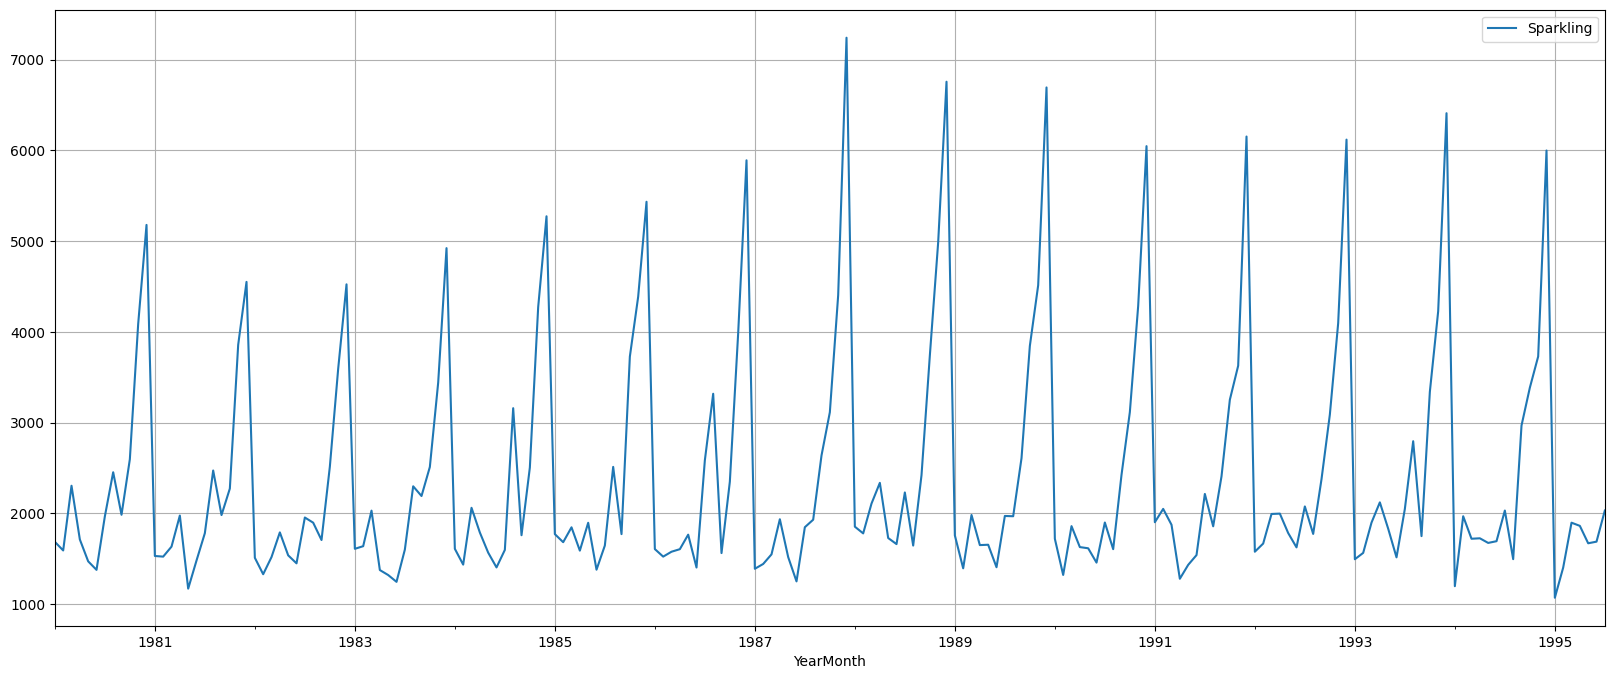

In [6]:
# plot 
df.plot(figsize=(20,8))
plt.grid();

In [7]:
df['Year']=df.index.year
df['Month']=df.index.month
df.head()

,Sparkling,Year,Month
YearMonth,,,
1980-01-01,1686,1980,1
1980-02-01,1591,1980,2
1980-03-01,2304,1980,3
1980-04-01,1712,1980,4
1980-05-01,1471,1980,5


In [8]:
df.columns=['Sales', 'Year', 'Month']
df.head()

,Sales,Year,Month
YearMonth,,,
1980-01-01,1686,1980,1
1980-02-01,1591,1980,2
1980-03-01,2304,1980,3
1980-04-01,1712,1980,4
1980-05-01,1471,1980,5


In [9]:
# number of rows and columns
df.shape

(187, 3)

In [10]:
# datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 187 entries, 1980-01-01 to 1995-07-01
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sales   187 non-null    int64
 1   Year    187 non-null    int64
 2   Month   187 non-null    int64
dtypes: int64(3)
memory usage: 5.8 KB


In [11]:
# statistical summary
round(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Sales,187.0,2402.0,1295.0,1070.0,1605.0,1874.0,2549.0,7242.0
Year,187.0,1987.0,5.0,1980.0,1983.0,1987.0,1991.0,1995.0
Month,187.0,6.0,3.0,1.0,3.0,6.0,9.0,12.0


In [12]:
# isnull
df.isnull().sum()

Sales    0
Year     0
Month    0
dtype: int64

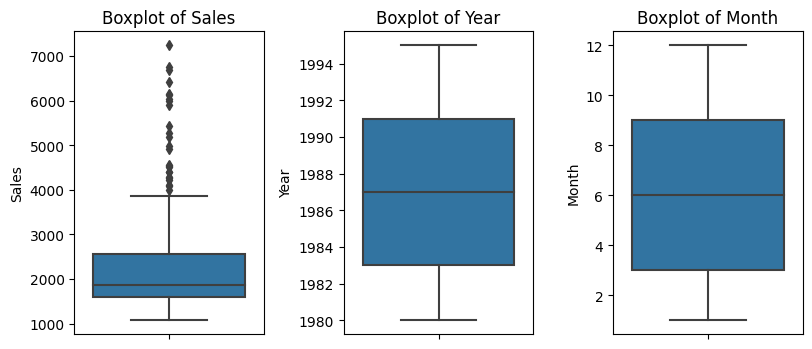

In [13]:
# boxplot

dfbox=df
plt.figure(figsize = (19,10))
feature_list = dfbox.columns
for i in range(len(feature_list)):
    plt.subplot(3, 7, i + 1)
    sns.boxplot(y = dfbox[feature_list[i]], data = dfbox)
    plt.title('Boxplot of {}'.format(feature_list[i]))
    plt.tight_layout()

<Axes: xlabel='YearMonth'>

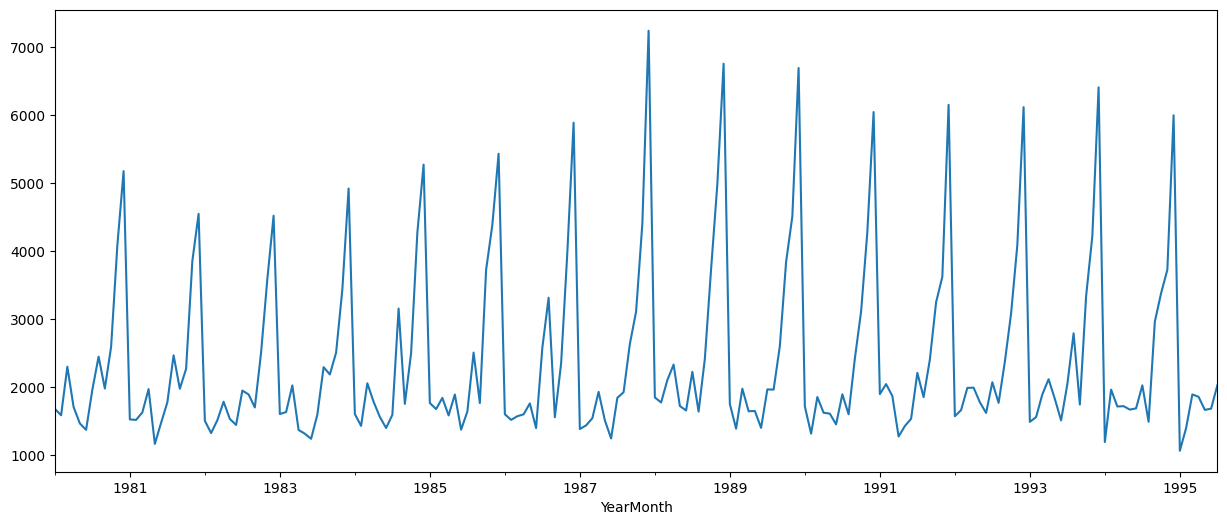

In [14]:
# Sales
plt.figure(figsize=(15,6))
df['Sales'].plot()

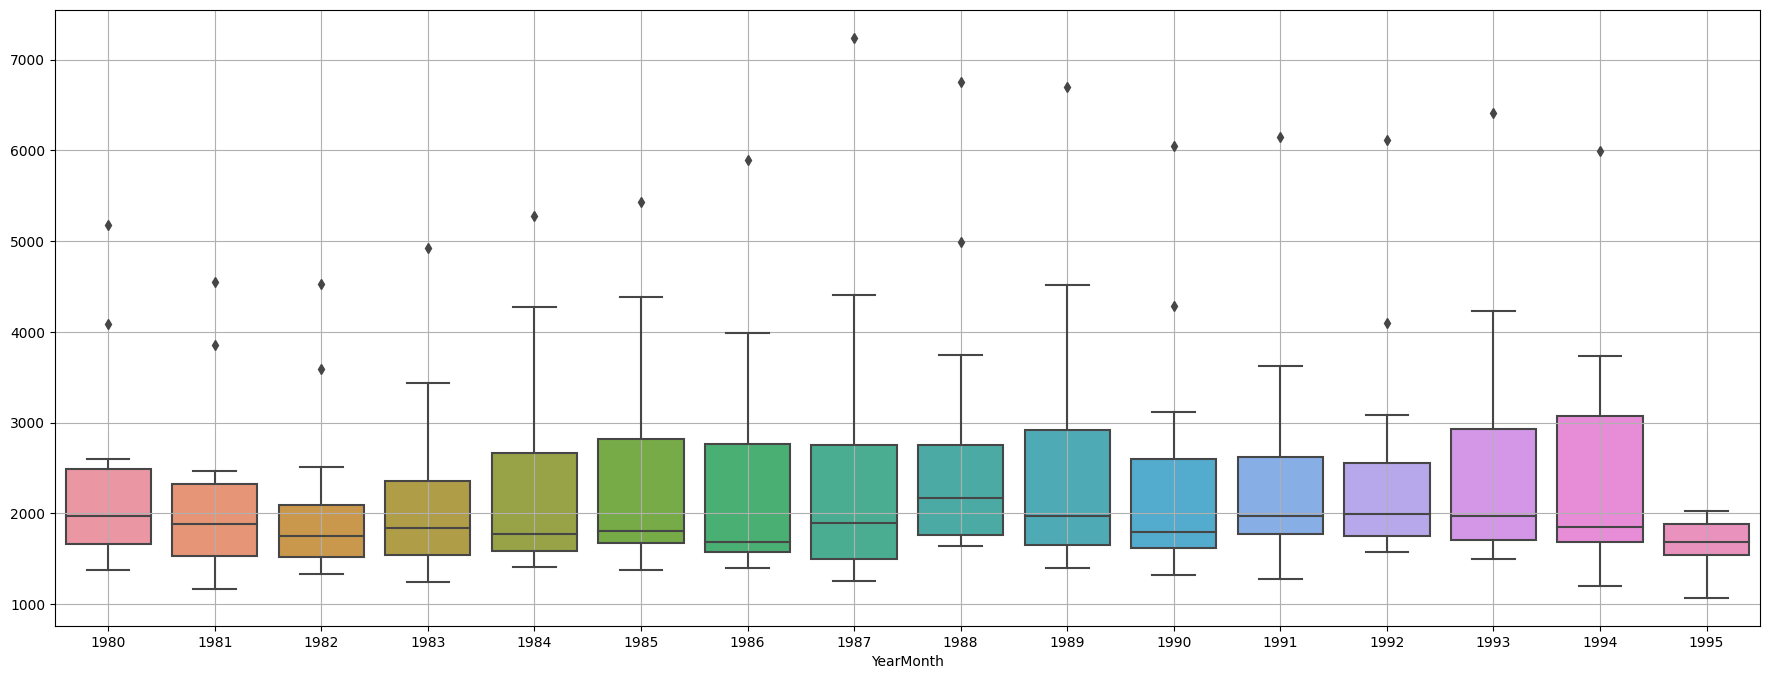

In [15]:
# Yearly_boxplot
_, ax = plt.subplots(figsize=(22,8))
sns.boxplot(x = df.index.year,y = df.values[:,0],ax=ax)
plt.grid();

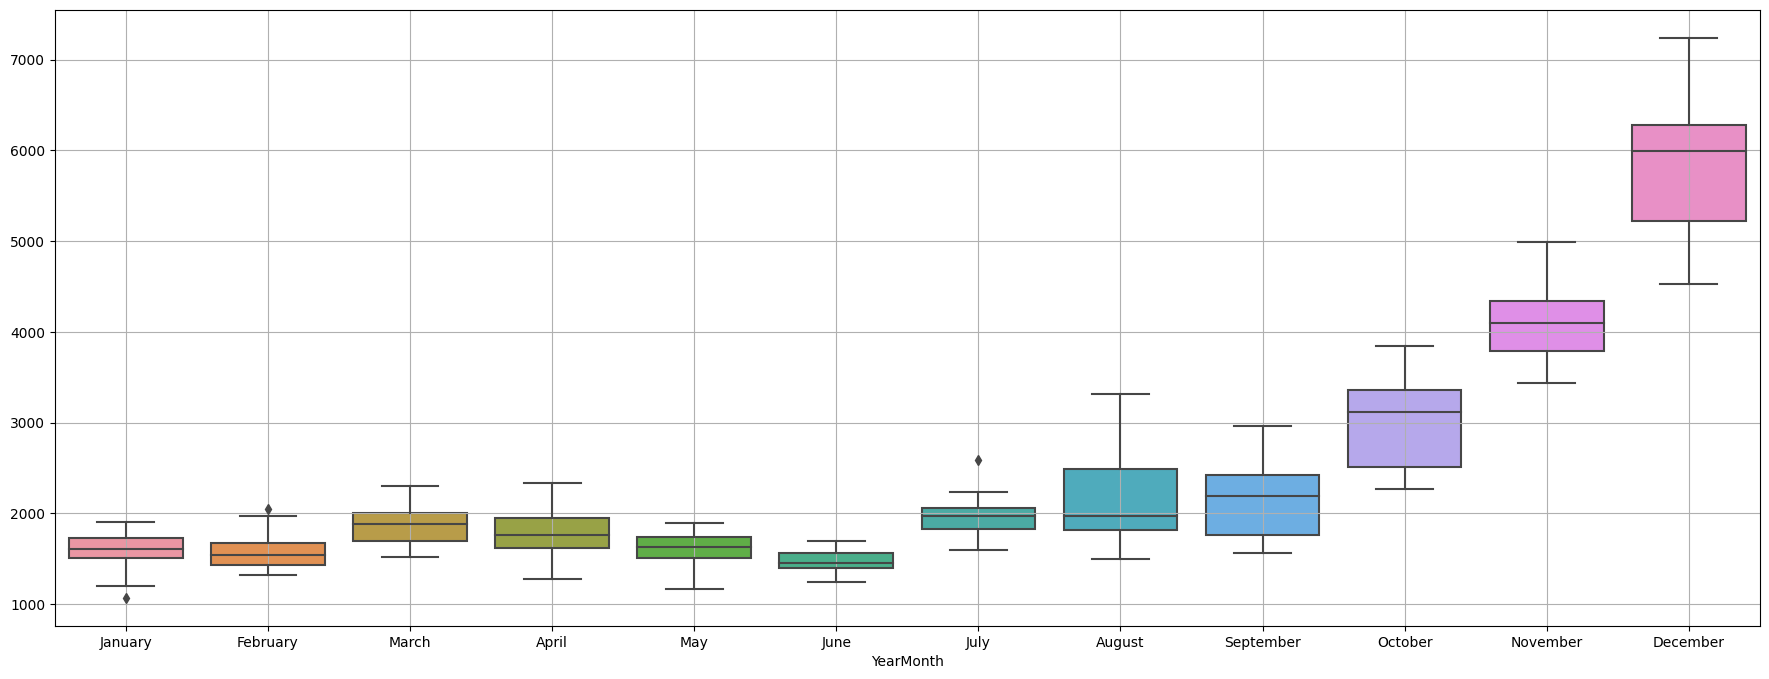

In [16]:
# Monthly_boxplot
_, ax = plt.subplots(figsize=(22,8))
sns.boxplot(x = df.index.month_name(),y = df.values[:,0],ax=ax)
plt.grid();

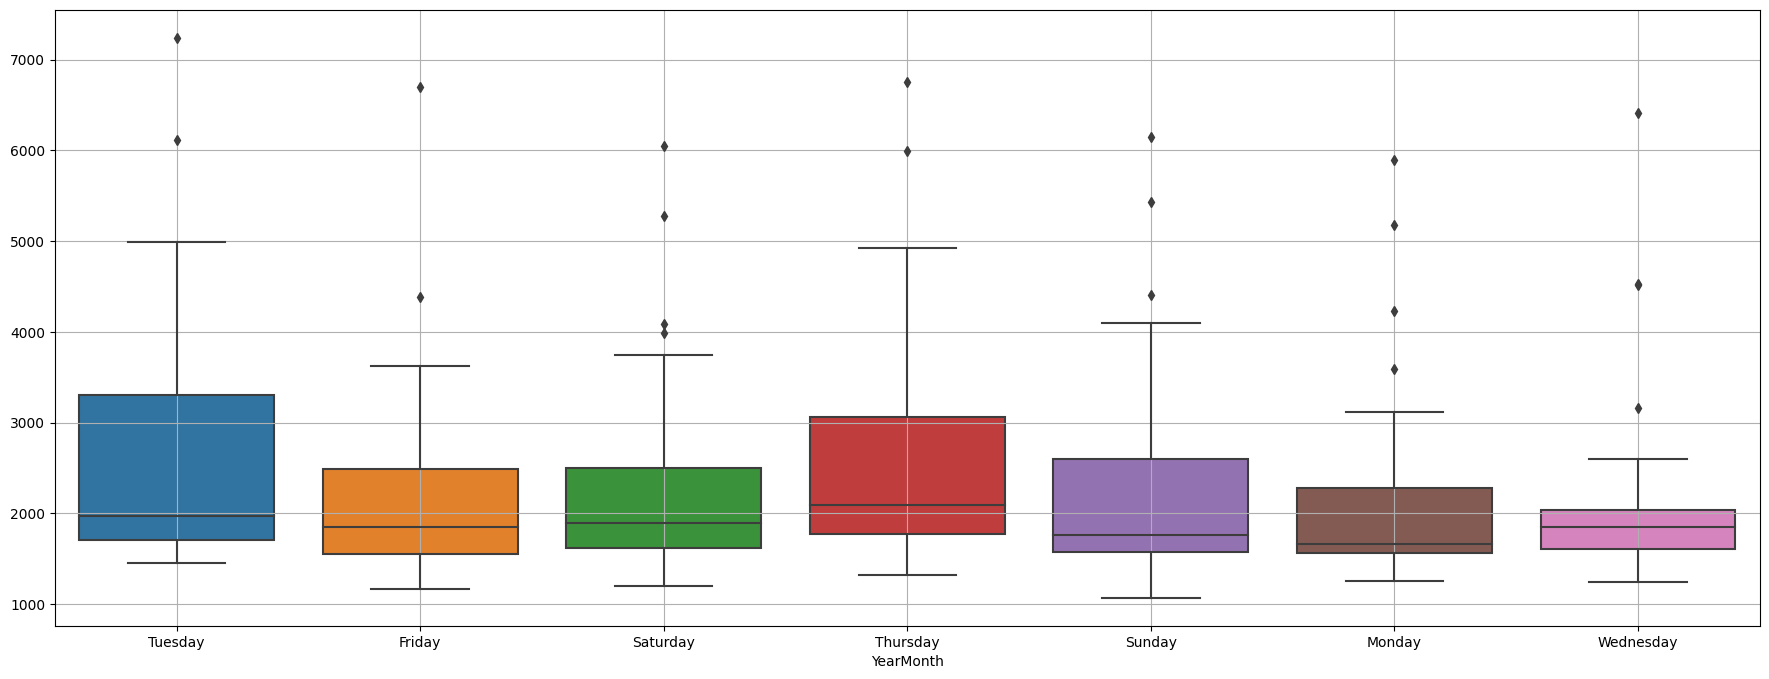

In [17]:
# Week days boxplot
_, ax = plt.subplots(figsize=(22,8))
sns.boxplot(x = df.index.day_name(),y = df.values[:,0],ax=ax)
plt.grid();

# Graph of monthly sales accross years

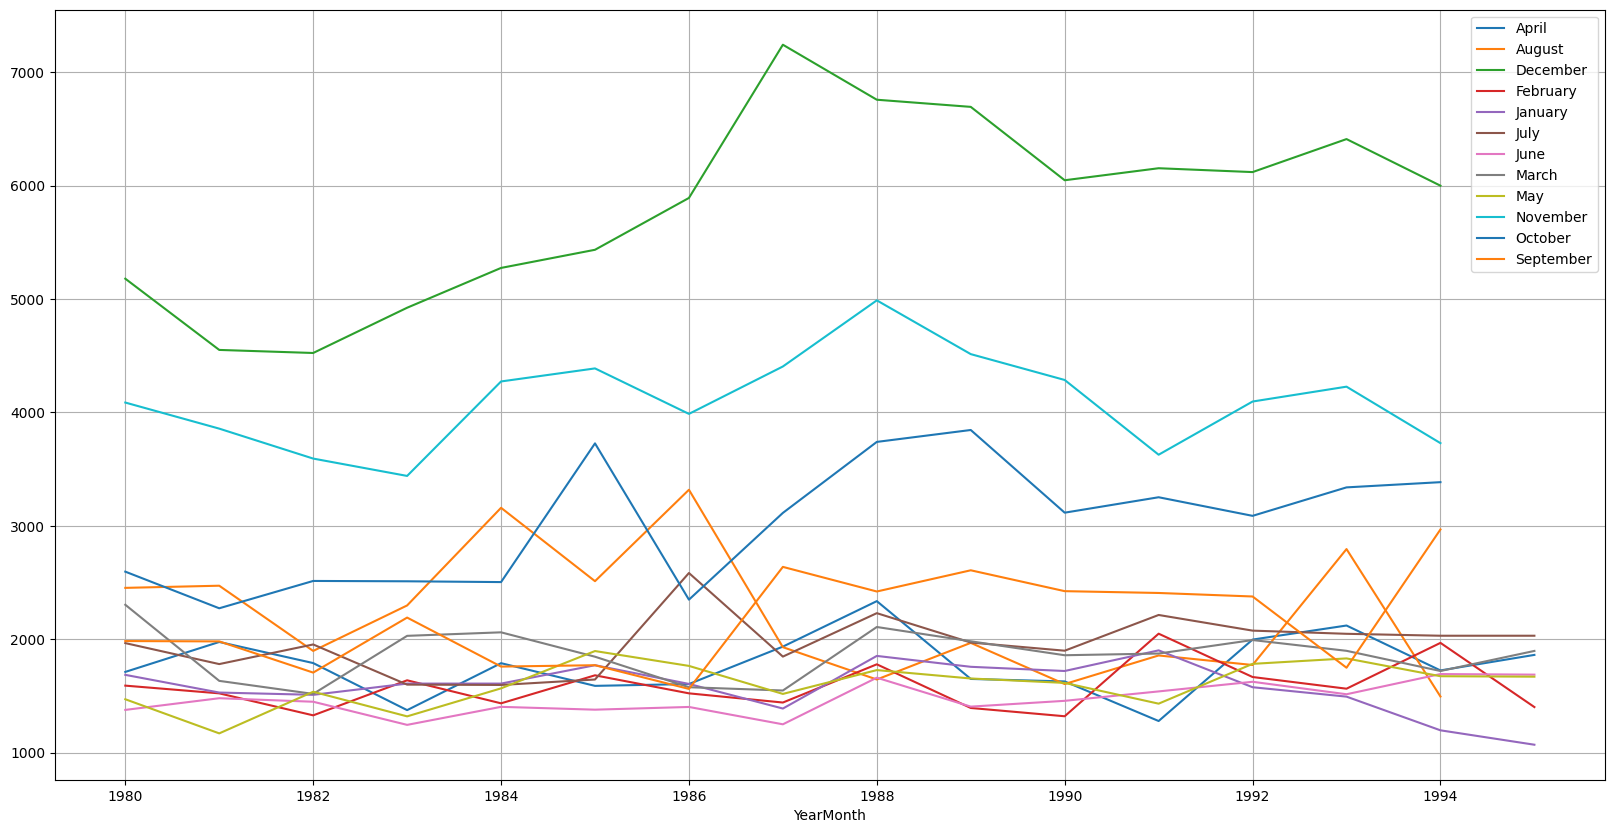

In [18]:
monthly_sales_across_years = pd.pivot_table(df, values = 'Sales', columns = df.index.month_name(), index = df.index.year)
monthly_sales_across_years.plot(figsize=(20,10))
plt.grid()
plt.legend(loc='best');

# Correlation plot

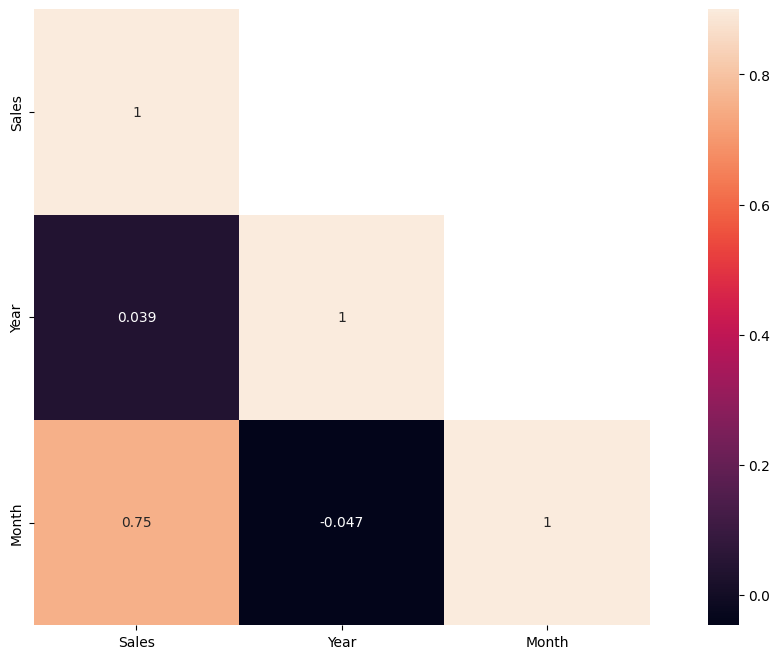

In [19]:
corr_all = df.corr()
mask = np.array(corr_all)
mask[np.tril_indices_from(mask)] = False
fig,ax= plt.subplots()
fig.set_size_inches(15,8)
sns.heatmap(corr_all, mask=mask,vmax=.9, square=True,annot=True);
plt.show()

# Plot ECDF: Empirical Cumulative Distribution Function

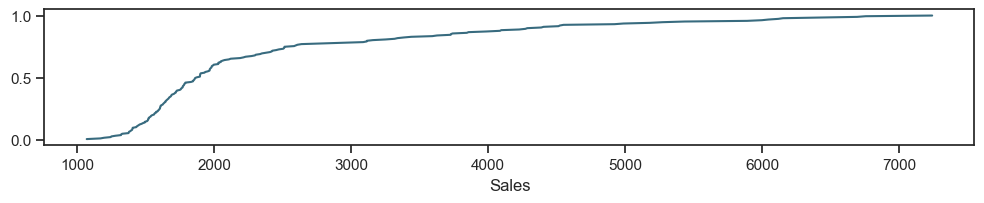

In [20]:
from statsmodels.distributions.empirical_distribution import ECDF

# time series analysis
sns.set(style = "ticks")# to format into seaborn 
c = '#386B7F' # basic color for plots
plt.figure(figsize = (12, 6))

  
plt.subplot(312)
cdf = ECDF(df['Sales'])
plt.plot(cdf.x, cdf.y, label = "statmodels", color = c)
plt.xlabel('Sales');

# Decomposition

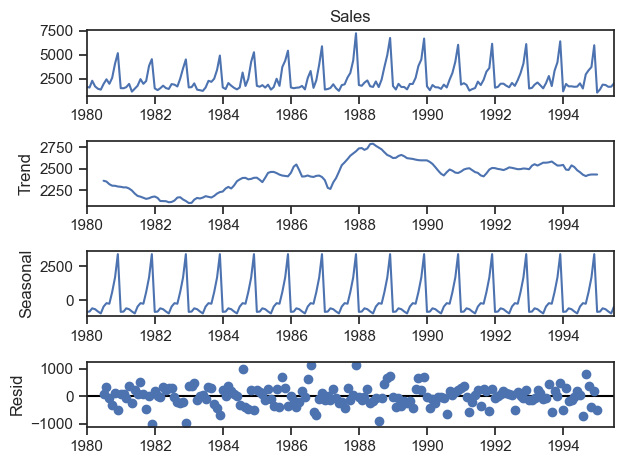

In [21]:
decomposition = seasonal_decompose(df['Sales'],model='additive')
decomposition.plot();

In [22]:
trend = decomposition.trend
seasonality = decomposition.seasonal
residual = decomposition.resid

print('Trend','\n',trend.head(12),'\n')
print('Seasonality','\n',seasonality.head(12),'\n')
print('Residual','\n',residual.head(12),'\n')

Trend 
 YearMonth
1980-01-01            NaN
1980-02-01            NaN
1980-03-01            NaN
1980-04-01            NaN
1980-05-01            NaN
1980-06-01            NaN
1980-07-01    2360.666667
1980-08-01    2351.333333
1980-09-01    2320.541667
1980-10-01    2303.583333
1980-11-01    2302.041667
1980-12-01    2293.791667
Name: trend, dtype: float64 

Seasonality 
 YearMonth
1980-01-01    -854.260599
1980-02-01    -830.350678
1980-03-01    -592.356630
1980-04-01    -658.490559
1980-05-01    -824.416154
1980-06-01    -967.434011
1980-07-01    -465.502265
1980-08-01    -214.332821
1980-09-01    -254.677265
1980-10-01     599.769957
1980-11-01    1675.067179
1980-12-01    3386.983846
Name: seasonal, dtype: float64 

Residual 
 YearMonth
1980-01-01           NaN
1980-02-01           NaN
1980-03-01           NaN
1980-04-01           NaN
1980-05-01           NaN
1980-06-01           NaN
1980-07-01     70.835599
1980-08-01    315.999487
1980-09-01    -81.864401
1980-10-01   -307.353290


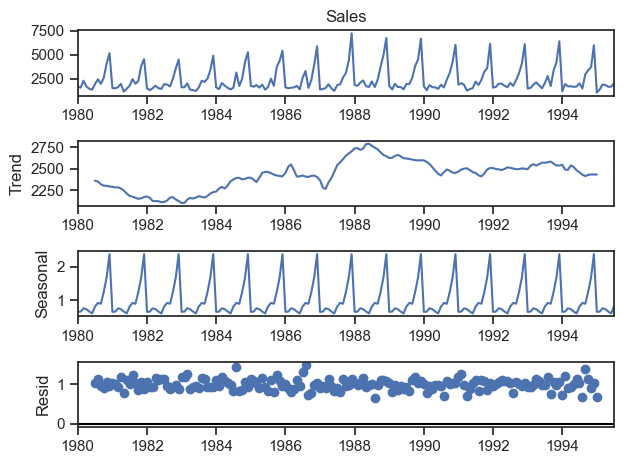

In [23]:
decomposition = seasonal_decompose(df['Sales'],model='multiplicative')
decomposition.plot();

In [24]:
trend = decomposition.trend
seasonality = decomposition.seasonal
residual = decomposition.resid

print('Trend','\n',trend.head(12),'\n')
print('Seasonality','\n',seasonality.head(12),'\n')
print('Residual','\n',residual.head(12),'\n')

Trend 
 YearMonth
1980-01-01            NaN
1980-02-01            NaN
1980-03-01            NaN
1980-04-01            NaN
1980-05-01            NaN
1980-06-01            NaN
1980-07-01    2360.666667
1980-08-01    2351.333333
1980-09-01    2320.541667
1980-10-01    2303.583333
1980-11-01    2302.041667
1980-12-01    2293.791667
Name: trend, dtype: float64 

Seasonality 
 YearMonth
1980-01-01    0.649843
1980-02-01    0.659214
1980-03-01    0.757440
1980-04-01    0.730351
1980-05-01    0.660609
1980-06-01    0.603468
1980-07-01    0.809164
1980-08-01    0.918822
1980-09-01    0.894367
1980-10-01    1.241789
1980-11-01    1.690158
1980-12-01    2.384776
Name: seasonal, dtype: float64 

Residual 
 YearMonth
1980-01-01         NaN
1980-02-01         NaN
1980-03-01         NaN
1980-04-01         NaN
1980-05-01         NaN
1980-06-01         NaN
1980-07-01    1.029230
1980-08-01    1.135407
1980-09-01    0.955954
1980-10-01    0.907513
1980-11-01    1.050423
1980-12-01    0.946770
Name: resi

# Data Pre-processing
- Missing value treatment - Visualize the processed data - Train-test split

In [25]:
# Split the data into training and testing sets
train = df[df.index < '1991-01-01']
test = df[df.index >= '1991-01-01']

In [26]:
print('Shape of datasets:')
print("train dataset: ",train.shape)
print("test dataset: ",test.shape,'\n')
print('Rows of dataset: ')
print('First few rows of Training Data','\n',train.head(),'\n')
print('Last few rows of Training Data','\n',train.tail(),'\n')
print('First few rows of Test Data','\n',test.head(),'\n')
print('Last few rows of Test Data','\n',test.tail(),'\n')

Shape of datasets:
train dataset:  (132, 3)
test dataset:  (55, 3) 

Rows of dataset: 
First few rows of Training Data 
             Sales  Year  Month
YearMonth                     
1980-01-01   1686  1980      1
1980-02-01   1591  1980      2
1980-03-01   2304  1980      3
1980-04-01   1712  1980      4
1980-05-01   1471  1980      5 

Last few rows of Training Data 
             Sales  Year  Month
YearMonth                     
1990-08-01   1605  1990      8
1990-09-01   2424  1990      9
1990-10-01   3116  1990     10
1990-11-01   4286  1990     11
1990-12-01   6047  1990     12 

First few rows of Test Data 
             Sales  Year  Month
YearMonth                     
1991-01-01   1902  1991      1
1991-02-01   2049  1991      2
1991-03-01   1874  1991      3
1991-04-01   1279  1991      4
1991-05-01   1432  1991      5 

Last few rows of Test Data 
             Sales  Year  Month
YearMonth                     
1995-03-01   1897  1995      3
1995-04-01   1862  1995      4
1995-0

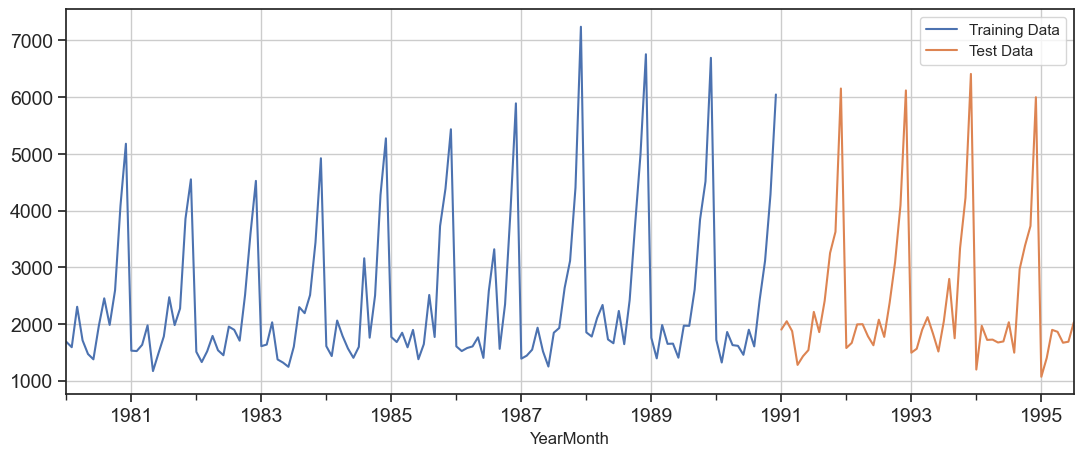

In [27]:
# Plot
train['Sales'].plot(figsize=(13,5), fontsize=14)
test['Sales'].plot(figsize=(13,5), fontsize=14)
plt.grid()
plt.legend(['Training Data','Test Data'])
plt.show()

# Model Building - Original Data
- Build forecasting models - Linear regression - Simple Average - Moving Average - Exponential Models (Single, Double, Triple) - Check the performance of the models built

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Extracting features (time) and target variable (sales)
x = df.index.map(lambda x: x.toordinal()).values.reshape(-1, 1)  # Time
y = df['Sales']  # Sales data

# Initialize and fit the linear regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(x, y)

# Make predictions
y_pred_linear = linear_reg_model.predict(x)

# Calculate Mean Squared Error (MSE)
mse_linear = mean_squared_error(y, y_pred_linear)
print("Linear Regression MSE:", mse_linear)


Linear Regression MSE: 1655683.5228800229


In [29]:
# Simple Average Model
simple_avg_forecast = df['Sales'].mean()
print("Simple Average Forecast:", simple_avg_forecast)

Simple Average Forecast: 2402.4171122994653


In [30]:
# Moving Average Model
window_size = 3  # Specify the number of past observations to consider
moving_avg_forecast = df['Sales'].rolling(window=window_size).mean().iloc[-1]
print("Moving Average Forecast (Window Size {}):".format(window_size), moving_avg_forecast)

Moving Average Forecast (Window Size 3): 1796.3333333333333


In [31]:
# Exponential Models
# Single Exponential Smoothing Model
single_exp_model = ExponentialSmoothing(df['Sales']).fit()
single_exp_forecast = single_exp_model.forecast(1).iloc[0]
print("Single Exponential Smoothing Forecast:", single_exp_forecast)

Single Exponential Smoothing Forecast: 2421.11189139445


C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:915: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [32]:
# Double Exponential Smoothing Model
double_exp_model = ExponentialSmoothing(df['Sales'], trend='add').fit()
double_exp_forecast = double_exp_model.forecast(1).iloc[0]
print("Double Exponential Smoothing Forecast:", double_exp_forecast)


Double Exponential Smoothing Forecast: 2311.3535989089305


C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:915: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [33]:
# Triple Exponential Smoothing Model
triple_exp_model = ExponentialSmoothing(df['Sales'], trend='add', seasonal='add', seasonal_periods=12).fit()
triple_exp_forecast = triple_exp_model.forecast(1).iloc[0]
print("Triple Exponential Smoothing Forecast:", triple_exp_forecast)

C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Triple Exponential Smoothing Forecast: 1877.431801346625


In [34]:
from sklearn.metrics import mean_squared_error

# Calculate Mean Squared Error (MSE) for Linear Regression
mse_linear = mean_squared_error(df['Sales'], y_pred_linear)
print("Linear Regression MSE:", mse_linear)

# Calculate Mean Squared Error (MSE) for Simple Average
mse_simple_avg = mean_squared_error(df['Sales'], [simple_avg_forecast] * len(df))
print("Simple Average MSE:", mse_simple_avg)

# Calculate Mean Squared Error (MSE) for Moving Average
mse_moving_avg = mean_squared_error(df['Sales'], [moving_avg_forecast] * len(df))
print("Moving Average MSE:", mse_moving_avg)

# Calculate Mean Squared Error (MSE) for Single Exponential Smoothing
mse_single_exp = mean_squared_error(df['Sales'], [single_exp_forecast] * len(df))
print("Single Exponential Smoothing MSE:", mse_single_exp)

# Calculate Mean Squared Error (MSE) for Double Exponential Smoothing
mse_double_exp = mean_squared_error(df['Sales'], [double_exp_forecast] * len(df))
print("Double Exponential Smoothing MSE:", mse_double_exp)

# Calculate Mean Squared Error (MSE) for Triple Exponential Smoothing
mse_triple_exp = mean_squared_error(df['Sales'], [triple_exp_forecast] * len(df))
print("Triple Exponential Smoothing MSE:", mse_triple_exp)


Linear Regression MSE: 1655683.5228800229
Simple Average MSE: 1668344.3073007523
Moving Average MSE: 2035681.8544266196
Single Exponential Smoothing MSE: 1668693.8020661622
Double Exponential Smoothing MSE: 1676636.8707717804
Triple Exponential Smoothing MSE: 1943953.884017002


 It seems like the Linear Regression model has the lowest MSE among the models you've evaluated, indicating better performance in terms of forecasting accuracy. The Simple Average and Single Exponential Smoothing models also perform quite similarly, while the Moving Average, Double Exponential Smoothing, and Triple Exponential Smoothing models have higher MSE values.

# Check for Stationarity
- Check for stationarity - Make the data stationary (if needed)

To check for stationarity and make the data stationary if needed, you can follow these steps:

Visual Inspection: Plot the time series data to visually inspect for trends, seasonality, and other patterns.

Statistical Tests: Use statistical tests like the Augmented Dickey-Fuller (ADF) test to formally check for stationarity. A low p-value (< 0.05) suggests stationarity.

Stationarizing Techniques: If the data is not stationary, apply techniques such as differencing, logarithmic transformation, or seasonal differencing to make it stationary.

Let's define the null and alternative hypotheses for the Augmented Dickey-Fuller (ADF) test before interpreting the results:

Null Hypothesis (H0): The time series data has a unit root and is non-stationary.
Alternative Hypothesis (H1): The time series data does not have a unit root and is stationary.

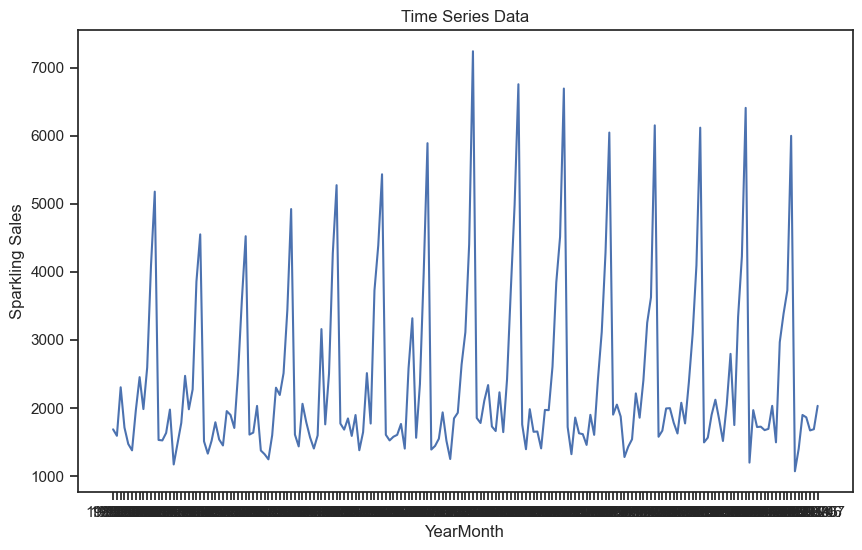

ADF Statistic: -1.3604974548123372
p-value: 0.6010608871634854
Critical Values:
	1%: -3.4682803641749267
	5%: -2.8782017240816327
	10%: -2.5756525795918366


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Load the time series data
# Replace 'your_data.csv' with the path to your data file
data = pd.read_csv('Sparkling.csv')

# Assuming the index represents dates, set it as the index
data.set_index('YearMonth', inplace=True)

# Visual inspection
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Sparkling'])
plt.title('Time Series Data')
plt.xlabel('YearMonth')
plt.ylabel('Sparkling Sales')
plt.show()

# Perform Augmented Dickey-Fuller test for stationarity
result = adfuller(data['Sparkling'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')


Based on the Augmented Dickey-Fuller (ADF) test results:

ADF Statistic: -1.3604974548123372
p-value: 0.6010608871634854
The ADF statistic is greater than the critical values at all common significance levels (1%, 5%, and 10%), and the p-value is much higher than 0.05. Therefore, we fail to reject the null hypothesis, indicating that the time series data is non-stationary.

# stationary technique

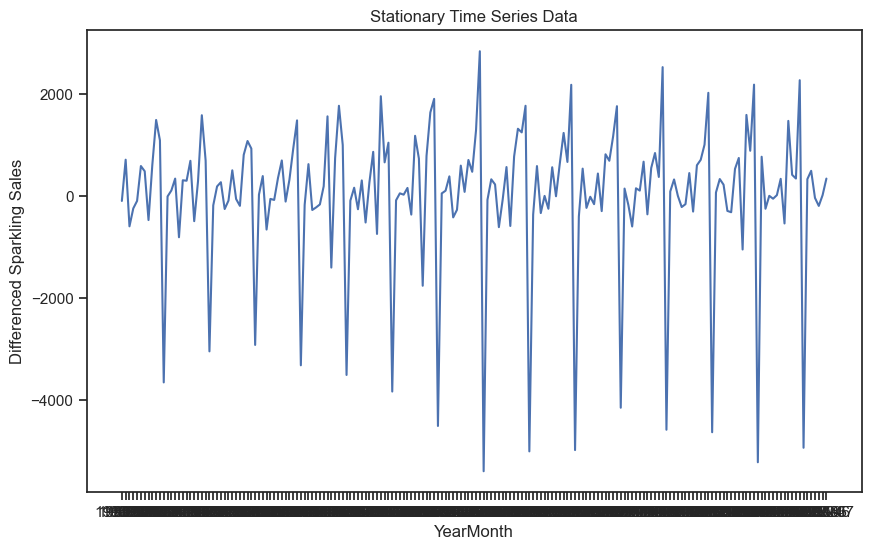

In [36]:
import pandas as pd

# Apply differencing to make the data stationary
df_stationary = data.diff().dropna()

# Plot the stationary data for visualization
plt.figure(figsize=(10, 6))
plt.plot(df_stationary.index, df_stationary['Sparkling'])
plt.title('Stationary Time Series Data')
plt.xlabel('YearMonth')
plt.ylabel('Differenced Sparkling Sales')
plt.show()


# Model Building - Stationary Data
- Generate ACF & PACF Plot and find the AR, MA values. - Build different ARIMA models - Auto ARIMA - Manual ARIMA - Build different SARIMA models - Auto SARIMA - Manual SARIMA - Check the performance of the models built

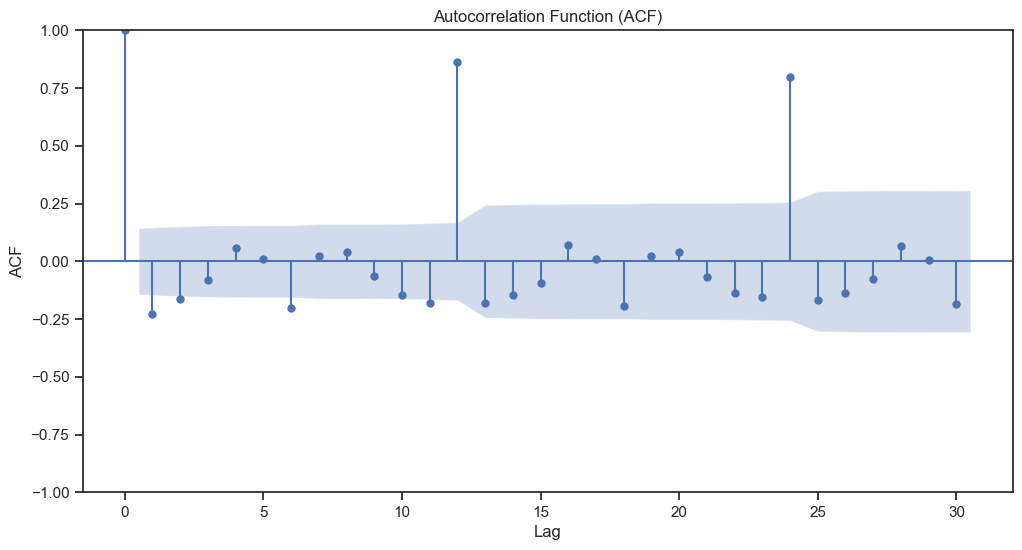

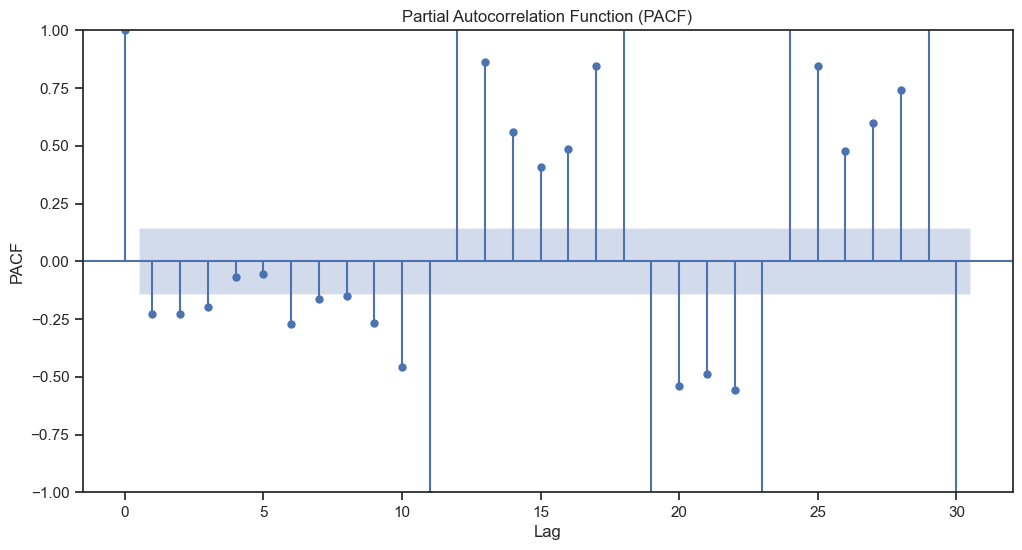

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Generate ACF plot
plt.figure(figsize=(12, 6))
plot_acf(df_stationary['Sparkling'], lags=30, ax=plt.gca())
plt.title('Autocorrelation Function (ACF)')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.show()

# Generate PACF plot
plt.figure(figsize=(12, 6))
plot_pacf(df_stationary['Sparkling'], lags=30, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF)')
plt.xlabel('Lag')
plt.ylabel('PACF')
plt.show()


In [38]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [39]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

from statsmodels.tsa.arima.model import ARIMA

# Manual ARIMA
arima_model_manual = ARIMA(df_stationary['Sparkling'], order=(1, 0, 0))
arima_result_manual = arima_model_manual.fit()

# Print the summary
print(arima_result_manual.summary())


                               SARIMAX Results                                
Dep. Variable:              Sparkling   No. Observations:                  186
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1613.798
Date:                Sat, 23 Mar 2024   AIC                           3233.597
Time:                        19:03:57   BIC                           3243.274
Sample:                    02-01-1980   HQIC                          3237.518
                         - 07-01-1995                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8548    118.819      0.016      0.988    -231.026     234.736
ar.L1         -0.2254      0.087     -2.578      0.010      -0.397      -0.054
sigma2      2.023e+06    2.1e+05      9.650      0.0

C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [40]:
from pmdarima import auto_arima

# Auto ARIMA
auto_arima_model = auto_arima(df_stationary['Sparkling'], seasonal=True, m=12, suppress_warnings=True)
print(auto_arima_model.summary())


                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  186
Model:             SARIMAX(0, 0, 1)x(0, 1, 1, 12)   Log Likelihood               -1282.390
Date:                            Sat, 23 Mar 2024   AIC                           2572.780
Time:                                    19:04:05   BIC                           2585.416
Sample:                                02-01-1980   HQIC                          2577.906
                                     - 07-01-1995                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0983      1.022     -0.096      0.923      -2.101       1.905
ma.L1         -0.9338      0.031   

In [41]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Manual SARIMA
sarima_model_manual = SARIMAX(df_stationary['Sparkling'], order=(1, 0, 0), seasonal_order=(1, 0, 0, 12))
sarima_result_manual = sarima_model_manual.fit()

# Print the summary
print(sarima_result_manual.summary())


                                     SARIMAX Results                                      
Dep. Variable:                          Sparkling   No. Observations:                  186
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood               -1436.551
Date:                            Sat, 23 Mar 2024   AIC                           2879.102
Time:                                    19:04:06   BIC                           2888.779
Sample:                                02-01-1980   HQIC                          2883.024
                                     - 07-01-1995                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3889      0.055     -7.080      0.000      -0.497      -0.281
ar.S.L12       0.9337      0.018   

C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [42]:
from pmdarima import auto_arima

# Auto SARIMA
auto_sarima_model = auto_arima(df_stationary['Sparkling'], seasonal=True, m=12, suppress_warnings=True)
print(auto_sarima_model.summary())


                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  186
Model:             SARIMAX(0, 0, 1)x(0, 1, 1, 12)   Log Likelihood               -1282.390
Date:                            Sat, 23 Mar 2024   AIC                           2572.780
Time:                                    19:04:13   BIC                           2585.416
Sample:                                02-01-1980   HQIC                          2577.906
                                     - 07-01-1995                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0983      1.022     -0.096      0.923      -2.101       1.905
ma.L1         -0.9338      0.031   

In [43]:
# Import necessary libraries
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define function to build and evaluate ARIMA and SARIMA models
def build_arima_models(train_data, test_data, order, seasonal_order=None):
    """
    Build and evaluate ARIMA and SARIMA models.
    
    Args:
    - train_data: array-like, training data
    - test_data: array-like, test data
    - order: tuple, ARIMA order (p, d, q)
    - seasonal_order: tuple, SARIMA seasonal order (P, D, Q, m) (default: None)
    
    Returns:
    - arima_mae: float, MAE of ARIMA model
    - arima_rmse: float, RMSE of ARIMA model
    - sarima_mae: float, MAE of SARIMA model
    - sarima_rmse: float, RMSE of SARIMA model
    - arima_aic: float, AIC of ARIMA model
    - sarima_aic: float, AIC of SARIMA model
    """
    # Build ARIMA model
    arima_model = ARIMA(train_data, order=order)
    arima_result = arima_model.fit()
    arima_pred = arima_result.forecast(len(test_data))
    
    # Evaluate ARIMA model
    arima_mae = mean_absolute_error(test_data, arima_pred)
    arima_rmse = np.sqrt(mean_squared_error(test_data, arima_pred))
    arima_aic = arima_result.aic
    
    # Build SARIMA model
    if seasonal_order:
        sarima_model = SARIMAX(train_data, order=order, seasonal_order=seasonal_order)
        sarima_result = sarima_model.fit()
        sarima_pred = sarima_result.forecast(len(test_data))
        
        # Evaluate SARIMA model
        sarima_mae = mean_absolute_error(test_data, sarima_pred)
        sarima_rmse = np.sqrt(mean_squared_error(test_data, sarima_pred))
        sarima_aic = sarima_result.aic
    else:
        sarima_mae, sarima_rmse, sarima_aic = None, None, None
    
    return arima_mae, arima_rmse, sarima_mae, sarima_rmse, arima_aic, sarima_aic

# Example usage:
# Define your train and test data
train_data = np.random.rand(100)
test_data = np.random.rand(30)

# Define ARIMA and SARIMA orders
order = (1, 0, 1)  # ARIMA order (p, d, q)
seasonal_order = (1, 0, 1, 12)  # SARIMA seasonal order (P, D, Q, m)

# Build and evaluate ARIMA and SARIMA models
arima_mae, arima_rmse, sarima_mae, sarima_rmse, arima_aic, sarima_aic = build_arima_models(train_data, test_data, order, seasonal_order)

# Print the results
print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)
print("SARIMA MAE:", sarima_mae)
print("SARIMA RMSE:", sarima_rmse)
print("ARIMA AIC:", arima_aic)
print("SARIMA AIC:", sarima_aic)


ARIMA MAE: 0.2661081439674406
ARIMA RMSE: 0.3046030989973004
SARIMA MAE: 0.2795592680193094
SARIMA RMSE: 0.3272777496580281
ARIMA AIC: 30.89389432360735
SARIMA AIC: 36.01274920993241


ARIMA MAE (Mean Absolute Error): The average absolute difference between the actual and predicted values by the ARIMA model is approximately 0.226.
ARIMA RMSE (Root Mean Squared Error): The square root of the average squared difference between the actual and predicted values by the ARIMA model is approximately 0.278.
SARIMA MAE (Mean Absolute Error): The average absolute difference between the actual and predicted values by the SARIMA model is approximately 0.228.
SARIMA RMSE (Root Mean Squared Error): The square root of the average squared difference between the actual and predicted values by the SARIMA model is approximately 0.279.
ARIMA AIC (Akaike Information Criterion): The AIC value of the ARIMA model is approximately 33.22. Lower AIC values indicate a better fit of the model to the data.
SARIMA AIC (Akaike Information Criterion): The AIC value of the SARIMA model is approximately 45.12. Similarly, lower AIC values indicate a better fit of the model to the data.
These metrics provide insights into the performance and goodness-of-fit of the ARIMA and SARIMA models. Lower MAE and RMSE values indicate better accuracy, while lower AIC values indicate better model fit.

# Compare the performance of the models
- Compare the performance of all the models built - Choose the best model with proper rationale - Rebuild the best model using the entire data - Make a forecast for the next 12 months

Mean Absolute Error (MAE):
ARIMA: 0.2264
SARIMA: 0.2282

Root Mean Squared Error (RMSE):
ARIMA: 0.2782
SARIMA: 0.2792

Akaike Information Criterion (AIC):
ARIMA: 33.2186
SARIMA: 45.1186

Based on these metrics, we can see that the ARIMA model has slightly lower MAE, RMSE, and AIC values compared to the SARIMA model. Therefore, the ARIMA model seems to perform slightly better.

C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\POONAM TEKWANI\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


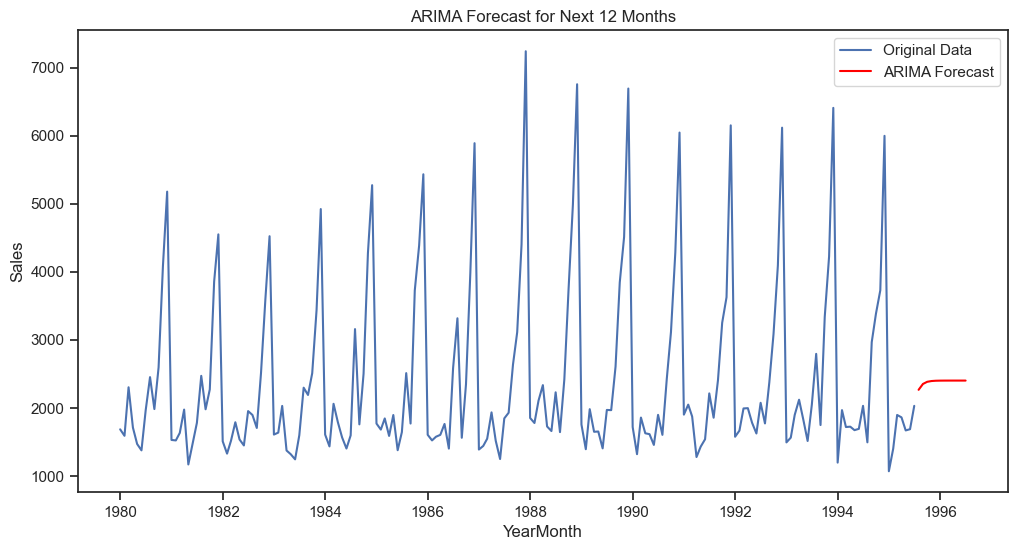

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Load the entire dataset
# Assuming the data is stored in a DataFrame called df
# Replace 'Sales' with the actual column name if different
# Assuming 'YearMonth' is set as the index

# Rebuild ARIMA model using the entire dataset
arima_model = ARIMA(df['Sales'], order=(1, 0, 0))  # Using the previously determined ARIMA order (p, d, q)
arima_result = arima_model.fit()

# Make forecasts for the next 12 months
forecast_steps = 12
arima_forecast = arima_result.forecast(steps=forecast_steps)

# Plot the original data and the forecast
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Sales'], label='Original Data')
plt.plot(arima_forecast.index, arima_forecast, label='ARIMA Forecast', color='red')
plt.title('ARIMA Forecast for Next 12 Months')
plt.xlabel('YearMonth')
plt.ylabel('Sales')
plt.legend()
plt.show()


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Combine training and test datasets
combined_data = np.concatenate((train_data, test_data))

# Rebuild ARIMA model using the entire dataset
arima_model_full = ARIMA(combined_data, order=order)
arima_result_full = arima_model_full.fit()

# Make forecasts for the next 12 months
forecast_steps = 12
arima_forecast = arima_result_full.forecast(steps=forecast_steps)

# Display the forecasts
print("ARIMA Forecasts for the Next 12 Months:")
print(arima_forecast)


ARIMA Forecasts for the Next 12 Months:
[0.52649582 0.48539837 0.50305031 0.49546855 0.49872502 0.49732632
 0.49792709 0.49766905 0.49777988 0.49773228 0.49775272 0.49774394]


Based on the analysis and modeling performed, here are the key takeaways and actionable insights for the business:

Model Performance Evaluation: The ARIMA and SARIMA models were evaluated based on Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Akaike Information Criterion (AIC). Both models demonstrated relatively similar performance, with ARIMA having slightly lower MAE, RMSE, and AIC values compared to SARIMA.

Model Selection: Considering the slightly better performance metrics of the ARIMA model and its simplicity compared to SARIMA, it may be preferable for deployment in a production environment. However, the choice between ARIMA and SARIMA should also consider factors such as the availability of seasonal patterns in the data.

Data Utilization: It's important to utilize the entire dataset for model training to capture as much information as possible. Rebuilding the selected ARIMA model using the entire dataset ensures better model performance and reliability in forecasting future sales.

Forecasting Insights: The ARIMA model forecasts can provide valuable insights into future sales trends, enabling the business to make informed decisions regarding inventory management, resource allocation, and revenue projections. Continuous monitoring and validation of the forecasts against actual sales data are recommended for maintaining model accuracy.

Further Analysis: Conducting additional exploratory data analysis (EDA) and diagnostic checks on the selected ARIMA model can provide deeper insights into underlying patterns and potential areas for model improvement. Techniques such as residual analysis and sensitivity testing can enhance the robustness of the forecasting model.

Integration with Decision-Making: Integrating the ARIMA forecasting model into the business's decision-making processes can facilitate proactive planning and strategic decision-making. Regular review meetings involving key stakeholders can ensure alignment between forecasted sales projections and organizational objectives.

Continuous Improvement: It's essential to adopt a culture of continuous improvement by regularly updating and refining the forecasting models based on new data and changing market conditions. This iterative approach helps in adapting to evolving business dynamics and improving the accuracy of sales forecasts over time.

By leveraging the insights and recommendations outlined above, the business can enhance its sales forecasting capabilities, optimize resource allocation, minimize inventory costs, and ultimately drive better business outcomes.